In [12]:
import random, warnings, collections
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT   = Path(r"/home/gastanvedad/Documents/CASIA2")
AU_DIR = ROOT / 'Au'
TP_DIR = ROOT / 'Tp'
EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

In [13]:
from PIL import Image

def load_rgb(path, maxdim=512):
    try:
        img = Image.open(path).convert('RGB')
    except Exception:
        return None
    w, h = img.size
    if max(w, h) > maxdim:
        s = maxdim / max(w, h)
        img = img.resize((max(1, int(w*s)), max(1, int(h*s))), Image.LANCZOS)
    return np.array(img, dtype=np.uint8)

def load_gray(path, maxdim=512):
    rgb = load_rgb(path, maxdim)
    return None if rgb is None else cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def get_tp_label(path):
    parts = path.stem.split('_')
    try:
        return 1 if parts[1] == 'S' else 2
    except Exception:
        return 2

In [14]:
def akaze_features(path, min_dist=15, ratio=0.93):
    img = load_gray(path)
    if img is None:
        return np.zeros(12, dtype=np.float32)

    kps, descs = cv2.AKAZE_create(threshold=0.0002).detectAndCompute(img, None)
    if descs is None or len(kps) < 8:
        return np.zeros(12, dtype=np.float32)

    candidates = []
    for trip in cv2.BFMatcher(cv2.NORM_HAMMING).knnMatch(descs, descs, k=4):
        ns = [m for m in trip if m.queryIdx != m.trainIdx]
        if len(ns) < 2: continue
        m, n = ns[0], ns[1]
        if m.distance <= ratio * n.distance:
            p1 = np.array(kps[m.queryIdx].pt, dtype=np.float32)
            p2 = np.array(kps[m.trainIdx].pt, dtype=np.float32)
            d  = p2 - p1
            if np.linalg.norm(d) > min_dist:
                candidates.append((p1, p2, d, m.distance))

    if len(candidates) < 5:
        return np.zeros(12, dtype=np.float32)

    disps = np.array([c[2] for c in candidates], dtype=np.float32)
    quant = np.round(disps / 4.0).astype(np.int16)
    keys, counts = np.unique(quant, axis=0, return_counts=True)

    # Displacement dominance: fraction of ALL candidates in the single best cluster
    # True copy-move → one translation dominates (high dominance)
    # Ornamental/texture → many directions, no single dominant cluster (low dominance)
    total_cands = len(candidates)
    best_count  = int(counts.max())
    displacement_dominance = float(best_count / total_cands)

    # Number of distinct displacement directions (quantised to 4px grid)
    # Low for copy-move (1-2 directions), high for ornamental patterns (many directions)
    n_directions = float(len(keys))
    # Entropy of the displacement distribution — high entropy = ornamental
    count_probs  = counts.astype(np.float32) / counts.sum()
    from scipy.stats import entropy as _entropy
    disp_entropy = float(_entropy(count_probs))

    mask    = np.all(quant == keys[np.argmax(counts)], axis=1)
    inliers = [c for c, k in zip(candidates, mask) if k]

    n_in = len(inliers)
    if n_in == 0:
        return np.zeros(12, dtype=np.float32)

    in_d  = np.array([c[2] for c in inliers], dtype=np.float32)
    lens  = np.linalg.norm(in_d, axis=1)
    angs  = np.arctan2(in_d[:, 1], in_d[:, 0])
    dists = np.array([c[3] for c in inliers], dtype=np.float32)
    pts   = np.array([c[0] for c in inliers], dtype=np.float32)
    in_ratio    = n_in / max(total_cands, 1)
    compactness = float(np.mean(np.linalg.norm(pts - pts.mean(axis=0), axis=1)))
    consistency = float(1.0 / (1.0 + lens.std()))
    mean_dd     = float(dists.mean())
    cm_score    = float((1 - np.exp(-n_in / 10.0)) * (0.5 + 0.5 * in_ratio))

    # Hard flag now requires high dominance to reject ornamental false positives
    cm_hard_flag = float(
        n_in >= 12 and
        in_ratio >= 0.25 and
        consistency >= 0.08 and
        mean_dd <= 80 and
        displacement_dominance >= 0.20   # at least 20% of ALL candidates share one direction
    )

    return np.array([cm_score, float(n_in), float(in_ratio), float(lens.mean()),
                     float(lens.std()), float(angs.std()), compactness, consistency,
                     mean_dd, cm_hard_flag, displacement_dominance, disp_entropy],
                    dtype=np.float32)

In [15]:
SRM_KERNELS = [
    np.array([[0,0,0],[0,-1,1],[0,0,0]], dtype=np.float32),
    np.array([[0,0,0],[0,-1,0],[0,1,0]], dtype=np.float32),
    np.array([[0,0,0],[0,-1,0],[0,0,1]], dtype=np.float32),
    np.array([[-1,2,-1],[2,-4,2],[-1,2,-1]], dtype=np.float32) / 4,
]

def srm_features(path):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(28, dtype=np.float32)

    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Y, Cr, Cb = ycbcr[:,:,0], ycbcr[:,:,1], ycbcr[:,:,2]

    def channel_stats(ch):
        res = np.mean([np.abs(cv2.filter2D(ch, -1, k)) for k in SRM_KERNELS], axis=0)
        h, w = ch.shape
        bs = max(16, min(h, w) // 6)
        stds = [res[r:r+bs, c:c+bs].std()
                for r in range(0, h-bs+1, bs) for c in range(0, w-bs+1, bs)]
        stds = np.array(stds) if stds else np.array([0.0])
        med  = np.median(stds)
        return [res.mean(), res.std(),
                stds.std() / (stds.mean() + 1e-8),
                float(kurtosis(res.ravel())), float(skew(res.ravel())),
                float(np.max(np.abs(stds - med)))]

    nY  = cv2.filter2D(Y,  -1, SRM_KERNELS[3])
    nCr = cv2.filter2D(Cr, -1, SRM_KERNELS[3])
    nCb = cv2.filter2D(Cb, -1, SRM_KERNELS[3])

    def safe_corr(a, b):
        c = np.corrcoef(a.ravel(), b.ravel())[0, 1]
        return float(c) if np.isfinite(c) else 0.0

    # Multi-scale noise variance inconsistency (Pan et al. 2012)
    # Key splicing signal: variance of local noise estimates across blocks
    # Splicing → one region has different noise level → high inter-block variance
    # Copy-move / authentic → uniform noise level throughout
    def noise_variance_inconsistency(ch, block_sizes=(16, 32, 64)):
        h, w = ch.shape
        scores = []
        for bs in block_sizes:
            if bs > min(h, w) // 2:
                scores.append(0.0)
                continue
            # Estimate local noise variance per block using MAD estimator
            noise_vars = []
            for r in range(0, h - bs + 1, bs):
                for c in range(0, w - bs + 1, bs):
                    block = ch[r:r+bs, c:c+bs]
                    # Robust noise estimate: median absolute deviation of high-pass residual
                    hp = cv2.filter2D(block, -1, SRM_KERNELS[3])
                    mad = float(np.median(np.abs(hp - np.median(hp))))
                    noise_vars.append(mad)
            if len(noise_vars) < 2:
                scores.append(0.0)
                continue
            nv = np.array(noise_vars)
            # Coefficient of variation of local noise estimates
            # High CV → noise is spatially inconsistent → splicing signal
            scores.append(float(nv.std() / (nv.mean() + 1e-8)))
        return scores  # 3 values per channel

    nvi_Y  = noise_variance_inconsistency(Y)
    nvi_Cr = noise_variance_inconsistency(Cr)

    feats = (channel_stats(Y) + channel_stats(Cr) + channel_stats(Cb) +
             [safe_corr(nY, nCr), safe_corr(nY, nCb), safe_corr(nCr, nCb),
              float(np.mean(np.abs(nCr - nCb)))] +
             nvi_Y + nvi_Cr)
    return np.array(feats, dtype=np.float32)  # 22 + 6 = 28 features

In [16]:
def selfsim_features(path, grid=4):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(10, dtype=np.float32)

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    h, w = gray.shape
    ph, pw = h // grid, w // grid
    if ph < 8 or pw < 8:
        return np.zeros(10, dtype=np.float32)

    patches = []
    for r in range(grid):
        for c in range(grid):
            p = gray[r*ph:(r+1)*ph, c*pw:(c+1)*pw].ravel().astype(np.float64)
            std = p.std()
            patches.append((p - p.mean()) / std if std > 1e-6 else p)

    patches = np.stack(patches)
    n = len(patches)
    sims = np.array([float(np.dot(patches[i], patches[j])) / len(patches[i])
                     for i in range(n) for j in range(i+1, n)], dtype=np.float32)
    sims = np.clip(sims, -1.0, 1.0)
    ss   = np.sort(sims)[::-1]

    sim_max  = float(sims.max())
    sim_mean = float(sims.mean())
    sim_std  = float(sims.std())

    # Outlier ratio: how much does the single best pair stand out from the rest?
    # True copy-move: ONE pair is much higher than all others → high outlier_ratio
    # Ornamental: many pairs are similarly high → low outlier_ratio (mean is close to max)
    outlier_ratio = float((sim_max - sim_mean) / (sim_std + 1e-8))

    # Concentration: fraction of total similarity mass in top-3 pairs
    # Copy-move: top-3 dominate → high concentration
    # Ornamental: similarity is spread across many pairs → low concentration
    top3_sum  = float(ss[:3].sum())
    total_sum = float(np.abs(sims).sum() + 1e-8)
    sim_concentration = top3_sum / total_sum

    # Count of pairs above 0.85 (ornamental → many, copy-move → few but extreme)
    n_high = int((sims > 0.85).sum())

    # Ratio of max to 90th percentile (copy-move: large gap; ornamental: no gap)
    p90 = float(np.percentile(sims, 90))
    max_to_p90 = float(sim_max / (p90 + 1e-8))

    return np.array([sim_max, sim_mean, sim_std, float(skew(sims)),
                     float(np.percentile(sims, 95)) / (sim_mean + 1e-8),
                     ss[0] / (ss[1] + 1e-8) if len(ss) > 1 else 1.0,
                     float(n_high), outlier_ratio, sim_concentration, max_to_p90],
                    dtype=np.float32)

In [17]:
def chroma_boundary_features(path, n_strips=8):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(11, dtype=np.float32)

    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Cr, Cb = ycbcr[:,:,1], ycbcr[:,:,2]

    def strip_stats(ch, axis=0):
        size = ch.shape[axis]
        step = size // n_strips
        if step < 2: return np.zeros(5, dtype=np.float32)
        bg = []
        for k in range(1, n_strips):
            idx = k * step
            d = np.abs(np.take(ch, idx, axis=axis).astype(np.float32) -
                       np.take(ch, idx-1, axis=axis).astype(np.float32))
            bg.append(float(d.mean()))
        bg = np.array(bg, dtype=np.float32)
        m = bg.mean()
        return np.array([bg.max(), m, bg.std() / (m + 1e-8),
                         bg.max() / (m + 1e-8), float(kurtosis(bg))], dtype=np.float32)

    gCr = cv2.Sobel(Cr, cv2.CV_32F, 1, 0)**2 + cv2.Sobel(Cr, cv2.CV_32F, 0, 1)**2
    gCb = cv2.Sobel(Cb, cv2.CV_32F, 1, 0)**2 + cv2.Sobel(Cb, cv2.CV_32F, 0, 1)**2
    cross = float(np.abs(np.sqrt(gCr + 1e-8) - np.sqrt(gCb + 1e-8)).std())

    return np.concatenate([strip_stats(Cr, 0), strip_stats(Cr, 1), [cross]]).astype(np.float32)

In [18]:
def illumination_features(path):
    rgb = load_rgb(path)
    if rgb is None:
        return np.zeros(6, dtype=np.float32)

    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, A, B = lab[:,:,0], lab[:,:,1], lab[:,:,2]
    cv = lambda ch: float(ch.std() / (abs(ch.mean()) + 1e-8))
    gL = np.sqrt(cv2.Sobel(L, cv2.CV_32F, 1, 0)**2 + cv2.Sobel(L, cv2.CV_32F, 0, 1)**2)
    return np.array([cv(L), cv(A), cv(B), gL.mean(), gL.std(),
                     float(np.percentile(gL, 95))], dtype=np.float32)

In [19]:
def dct_markov_features(path, T=3):
    rgb = load_rgb(path)
    dim = 4 * (2*T+1)**2
    if rgb is None:
        return np.zeros(dim, dtype=np.float32)

    Y = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)[:,:,0]
    h8, w8 = (Y.shape[0]//8)*8, (Y.shape[1]//8)*8
    Y = Y[:h8, :w8]
    bh, bw = h8//8, w8//8

    from scipy.fft import dctn
    blocks = Y.reshape(bh, 8, bw, 8).transpose(0, 2, 1, 3)
    dct_b  = np.array([[dctn(blocks[i,j], norm='ortho') for j in range(bw)] for i in range(bh)])
    Q = np.round(dct_b.transpose(0,2,1,3).reshape(h8, w8)).astype(np.int32)

    def trans_prob(d):
        d = np.clip(d.ravel(), -T, T) + T
        s = 2*T+1
        counts = np.bincount(d[:-1]*s + d[1:], minlength=s*s).astype(np.float32).reshape(s, s)
        rs = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        return (counts / rs).ravel()

    parts = []
    for diff in [Q[:,:-1]-Q[:,1:], Q[:-1,:]-Q[1:,:],
                 Q[:,:-8:8]-Q[:,8::8], Q[:-8:8,:]-Q[8::8,:]]:
        parts.append(trans_prob(diff) if diff.size >= 2 else np.zeros((2*T+1)**2, dtype=np.float32))
    return np.concatenate(parts).astype(np.float32)

In [20]:
CM_HARD_FLAG_IDX       = 9
DISP_DOMINANCE_IDX     = 10
DISP_ENTROPY_IDX       = 11

# Layout: AKAZE:0-11(12), DCT Markov:12-207(196), SRM:208-235(28),
#         Illum:236-241(6), Selfsim:242-251(10), Chroma:252-262(11)
# Total: 263

FEATURE_NAMES = (
    ['cm_score','n_inliers','inlier_ratio','disp_mean','disp_std','angle_std',
     'cluster_compactness','disp_consistency','mean_desc_dist','cm_hard_flag',
     'displacement_dominance','disp_entropy']
    + [f'dct_markov_{i}' for i in range(196)]
    + [f'srm_{i}'        for i in range(28)]
    + [f'illum_{i}'      for i in range(6)]
    + [f'selfsim_{i}'    for i in range(10)]
    + [f'chroma_bnd_{i}' for i in range(11)]
)

CM_SP_FEAT_IDX = (
    list(range(0,  12))   # AKAZE (incl. dominance + entropy)
    + list(range(208, 236))  # SRM (incl. multi-scale noise variance)
    + list(range(236, 242))  # Illumination
    + list(range(242, 252))  # Self-similarity (incl. outlier_ratio, concentration)
    + list(range(252, 263))  # Chroma boundary
)

def extract_features(path):
    akaze  = akaze_features(path)
    markov = dct_markov_features(path)
    srm    = srm_features(path)
    illum  = illumination_features(path)
    ss     = selfsim_features(path)
    cb     = chroma_boundary_features(path)
    return np.concatenate([akaze, markov, srm, illum, ss, cb]).astype(np.float32)

def build_dataset(N=500):
    au = sorted([p for p in AU_DIR.iterdir() if p.suffix.lower() in EXTS])
    tp = sorted([p for p in TP_DIR.iterdir() if p.suffix.lower() in EXTS])
    cm = [p for p in tp if get_tp_label(p) == 1]
    sp = [p for p in tp if get_tp_label(p) == 2]
    print(f"Found: {len(au)} authentic, {len(cm)} copy-move, {len(sp)} spliced")

    X, y = [], []
    for label, paths, name in [(0, random.sample(au, min(N, len(au))), 'Authentic'),
                                (1, random.sample(cm, min(N, len(cm))), 'Copy-Move'),
                                (2, random.sample(sp, min(N, len(sp))), 'Splicing')]:
        for i, p in enumerate(paths):
            if i % 50 == 0: print(f"  [{name}] {i}/{len(paths)}", flush=True)
            try:
                feat = np.nan_to_num(extract_features(p), nan=0.0, posinf=0.0, neginf=0.0)
                X.append(feat); y.append(label)
            except Exception as e:
                print(f"    SKIP {p.name}: {e}")

    return np.array(X, dtype=np.float32), np.array(y)

X, y = build_dataset(N=500)
print(f"\nDataset: {X.shape}, classes: {collections.Counter(y)}")
assert X.shape[1] == 263, f"Expected 263 features, got {X.shape[1]}"

Found: 7491 authentic, 3274 copy-move, 1849 spliced
  [Authentic] 0/500
  [Authentic] 50/500
  [Authentic] 100/500
  [Authentic] 150/500
  [Authentic] 200/500
  [Authentic] 250/500
  [Authentic] 300/500
  [Authentic] 350/500
  [Authentic] 400/500
  [Authentic] 450/500
  [Copy-Move] 0/500
  [Copy-Move] 50/500
  [Copy-Move] 100/500
  [Copy-Move] 150/500
  [Copy-Move] 200/500
  [Copy-Move] 250/500
  [Copy-Move] 300/500
  [Copy-Move] 350/500
  [Copy-Move] 400/500
  [Copy-Move] 450/500
  [Splicing] 0/500
  [Splicing] 50/500
  [Splicing] 100/500
  [Splicing] 150/500
  [Splicing] 200/500
  [Splicing] 250/500
  [Splicing] 300/500
  [Splicing] 350/500
  [Splicing] 400/500
  [Splicing] 450/500

Dataset: (1500, 263), classes: Counter({np.int64(0): 500, np.int64(1): 500, np.int64(2): 500})


              precision    recall  f1-score   support

   Authentic       0.95      0.84      0.89       125
   Copy-Move       0.62      0.65      0.64       125
    Splicing       0.66      0.70      0.68       125

    accuracy                           0.73       375
   macro avg       0.74      0.73      0.73       375
weighted avg       0.74      0.73      0.73       375

Balanced Accuracy: 0.731
CV Balanced Accuracy: 0.745 ± 0.013


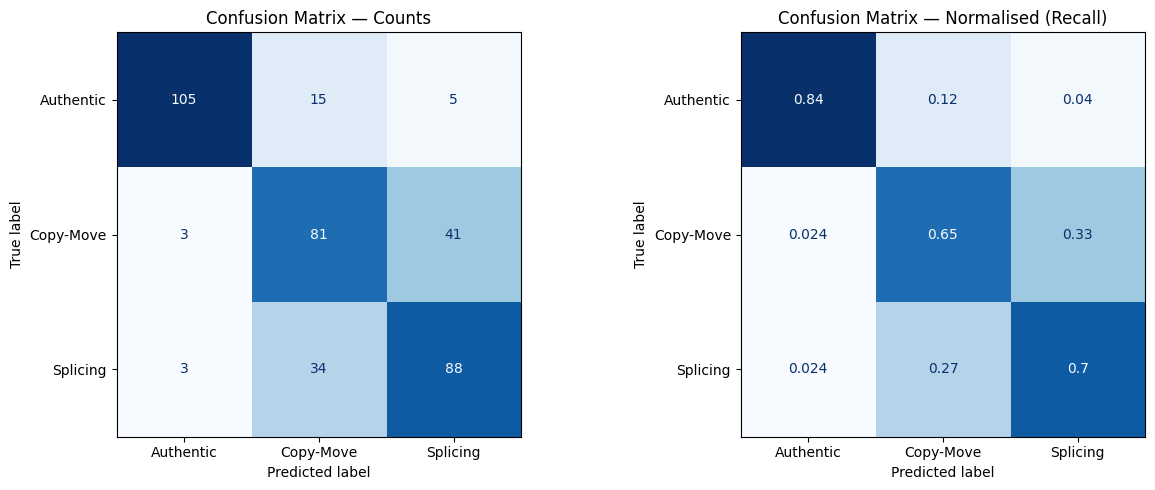

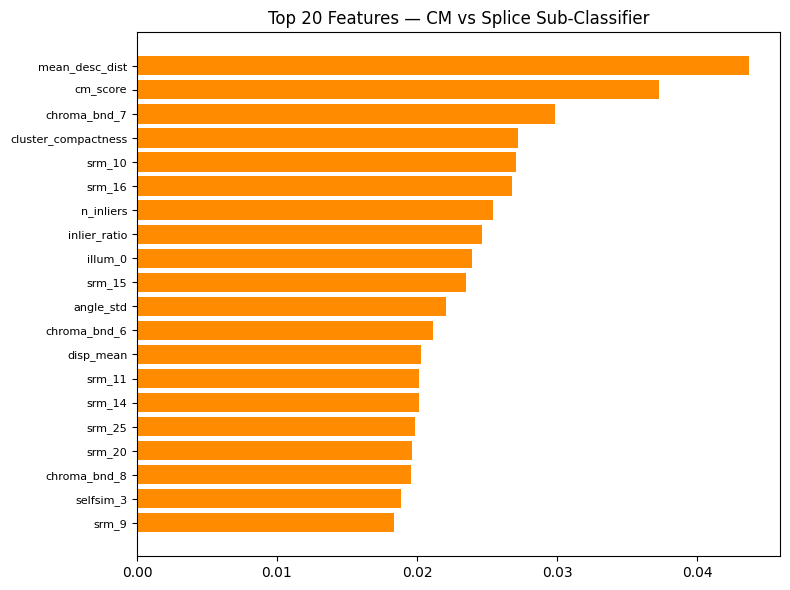

In [21]:
def train_and_evaluate(X, y):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

    sc1 = StandardScaler()
    clf1 = GradientBoostingClassifier(n_estimators=400, max_depth=5, learning_rate=0.07,
                                      subsample=0.8, min_samples_leaf=3,
                                      max_features='sqrt', random_state=42)
    clf1.fit(sc1.fit_transform(Xtr), ytr)

    tam = ytr != 0
    sc2 = StandardScaler()
    clf2 = GradientBoostingClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                                      subsample=0.8, min_samples_leaf=3,
                                      max_features='sqrt', random_state=42)
    clf2.fit(sc2.fit_transform(Xtr[tam][:, CM_SP_FEAT_IDX]), ytr[tam])

    def predict(Xr):
        Xr = np.nan_to_num(Xr, nan=0.0, posinf=0.0, neginf=0.0)
        preds = clf1.predict(sc1.transform(Xr)).copy()
        tam_m = preds != 0
        if tam_m.sum() > 0:
            preds[tam_m] = clf2.predict(sc2.transform(Xr[tam_m][:, CM_SP_FEAT_IDX]))
        # Hard override: cm_hard_flag=1 AND high displacement dominance
        # Dominance check rejects ornamental patterns (which spread across many directions)
        hard_flag   = (Xr[:, CM_HARD_FLAG_IDX] > 0.5) & (Xr[:, DISP_DOMINANCE_IDX] >= 0.20)
        is_tampered = preds != 0
        preds[hard_flag & is_tampered] = 1
        return preds

    preds = predict(Xte)
    print(classification_report(yte, preds, target_names=['Authentic','Copy-Move','Splicing']))
    print('Balanced Accuracy:', f"{balanced_accuracy_score(yte, preds):.3f}")

    scores = cross_val_score(
        Pipeline([('s', StandardScaler()),
                  ('c', GradientBoostingClassifier(n_estimators=400, max_depth=5,
                       learning_rate=0.07, subsample=0.8, min_samples_leaf=3,
                       max_features='sqrt', random_state=42))]),
        X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='balanced_accuracy', n_jobs=1)
    print(f'CV Balanced Accuracy: {scores.mean():.3f} ± {scores.std():.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    labels = ['Authentic','Copy-Move','Splicing']
    for ax, (cm_mat, title) in zip(axes, [
        (confusion_matrix(yte, preds), 'Counts'),
        (confusion_matrix(yte, preds, normalize='true'), 'Normalised (Recall)')]):
        ConfusionMatrixDisplay(cm_mat, display_labels=labels).plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Confusion Matrix — {title}')
    plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

    imps  = clf2.feature_importances_
    names = [FEATURE_NAMES[i] for i in CM_SP_FEAT_IDX]
    order = np.argsort(imps)[::-1][:20]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(len(order)), imps[order][::-1], color='darkorange')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([names[i] for i in order[::-1]], fontsize=8)
    ax.set_title('Top 20 Features — CM vs Splice Sub-Classifier')
    plt.tight_layout(); plt.show()

    return clf1, clf2, sc1, sc2, predict

clf1, clf2, sc1, sc2, predict_fn = train_and_evaluate(X, y)

Found 4 misclassified Copy-Move images and 368 misclassified Splicing images.


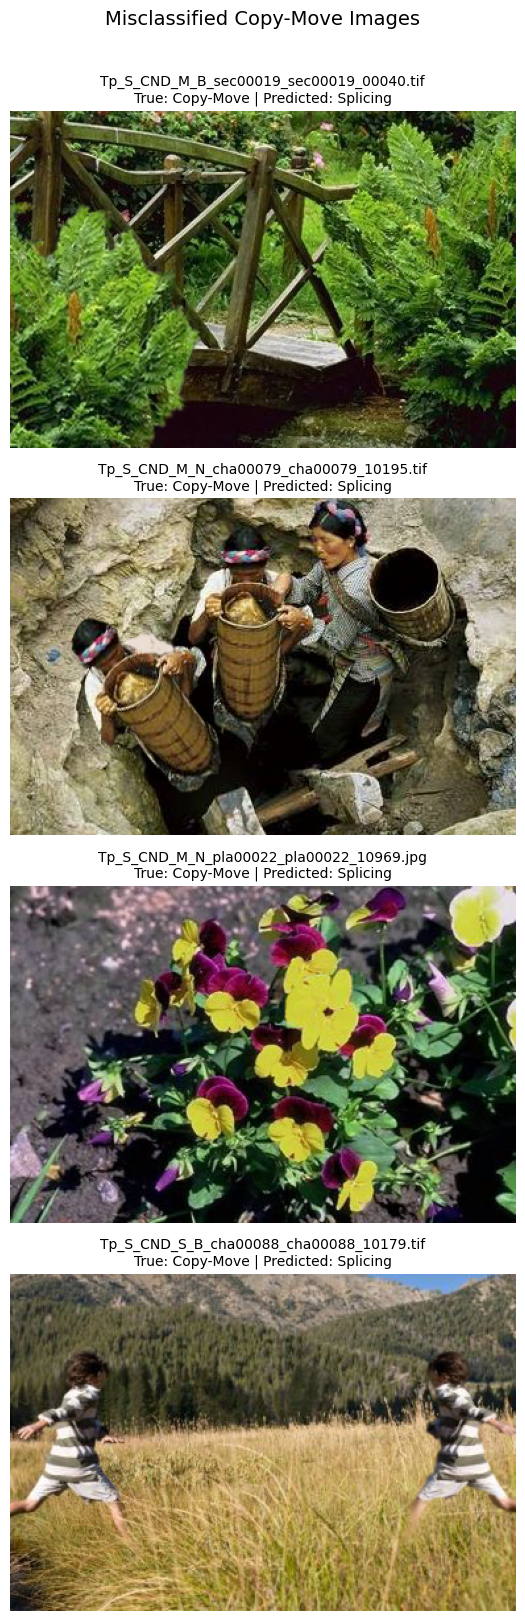

KeyboardInterrupt: 

In [22]:
def collect_misclassified_tampered(predictor, per_class=4):
    eligible = [p for p in TP_DIR.iterdir() if p.suffix.lower() in EXTS and 'txt' not in p.name.lower()]
    misclassified = {1: [], 2: []}
    label_names = {1: 'Copy-Move', 2: 'Splicing'}

    for path in eligible:
        true_label = get_tp_label(path)
        if true_label not in misclassified:
            continue

        try:
            feats = np.nan_to_num(extract_features(path), nan=0.0, posinf=0.0, neginf=0.0)[None, :]
            pred_label = int(predictor(feats)[0])
        except Exception as exc:
            print(f'SKIP {path.name}: {exc}')
            continue

        if pred_label != true_label:
            misclassified[true_label].append((path, true_label, pred_label))
            if all(len(misclassified[k]) >= per_class for k in misclassified):
                break

    return misclassified[1], misclassified[2]


def show_misclassified_examples(rows, title):
    label_names = {0: 'Authentic', 1: 'Copy-Move', 2: 'Splicing'}
    if not rows:
        print(f'No misclassified {title.lower()} examples found in the scanned set.')
        return

    fig, axes = plt.subplots(len(rows), 1, figsize=(10, 4 * len(rows)))
    if len(rows) == 1:
        axes = [axes]

    for ax, (path, true_label, pred_label) in zip(axes, rows):
        rgb = load_rgb(path)
        if rgb is None:
            ax.axis('off')
            ax.set_title(f'{path.name}\nUnable to load image')
            continue

        ax.imshow(rgb)
        ax.axis('off')
        ax.set_title(
            f'{path.name}\nTrue: {label_names[true_label]} | Predicted: {label_names[pred_label]}',
            fontsize=10
        )

    plt.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


cm_mis, sp_mis = collect_misclassified_tampered(predict_fn, per_class=4)
print(f'Found {len(cm_mis)} misclassified Copy-Move images and {len(sp_mis)} misclassified Splicing images.')
show_misclassified_examples(cm_mis, 'Misclassified Copy-Move Images')
show_misclassified_examples(sp_mis, 'Misclassified Splicing Images')